<a href="https://colab.research.google.com/github/emanaak04-svg/sleep-apnea-detection/blob/main/amna/feature_importance_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 01: Install Libraries and Mount Google Drive
We install required libraries and connect Google Drive
to access both Random Forest and XGBoost feature importance
files for comparison.

In [ ]:
from google.colab import drive
drive.mount('/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("All libraries imported")

Mounted at /drive
All libraries imported


## 02: Load Both Feature Importance Tables
We load the feature importance results from Random Forest
(Eman) and XGBoost (Amna) to compare which
features each model considered most important.

In [ ]:
df_rf = pd.read_csv("/drive/MyDrive/shhs-data/rf_feature_importance.csv")
df_xgb = pd.read_csv("/drive/MyDrive/shhs-data/xgb_feature_importance.csv")

print(f"Both feature importance tables loaded")
print(f"\nRandom Forest Top 10:")
print(df_rf.head(10).to_string(index=False))
print(f"\nXGBoost Top 10:")
print(df_xgb.head(10).to_string(index=False))

Both feature importance tables loaded

Random Forest Top 10:
          feature  importance
         cnn_prob    0.204931
      theta_power    0.073997
breath_regularity    0.060131
 delta_beta_ratio    0.059047
   mean_amplitude    0.049377
         ie_ratio    0.042090
      delta_power    0.039238
   breathing_rate    0.038925
         rel_beta    0.038067
   mean_peak_dist    0.037044

XGBoost Top 10:
          feature  importance
         cnn_prob    0.284764
    std_amplitude    0.095657
 delta_beta_ratio    0.068109
        rel_delta    0.039890
   mean_amplitude    0.037257
   mean_peak_dist    0.036994
breath_regularity    0.036926
      theta_power    0.035493
      apnea_index    0.029656
      delta_power    0.029413


## 03: Plot Top 10 Feature Importance — Side by Side Comparison
We plot a side-by-side bar chart comparing the top 10 most
important features for Random Forest and XGBoost.
This shows whether both models agree on which signals
matter most for detecting sleep apnea.

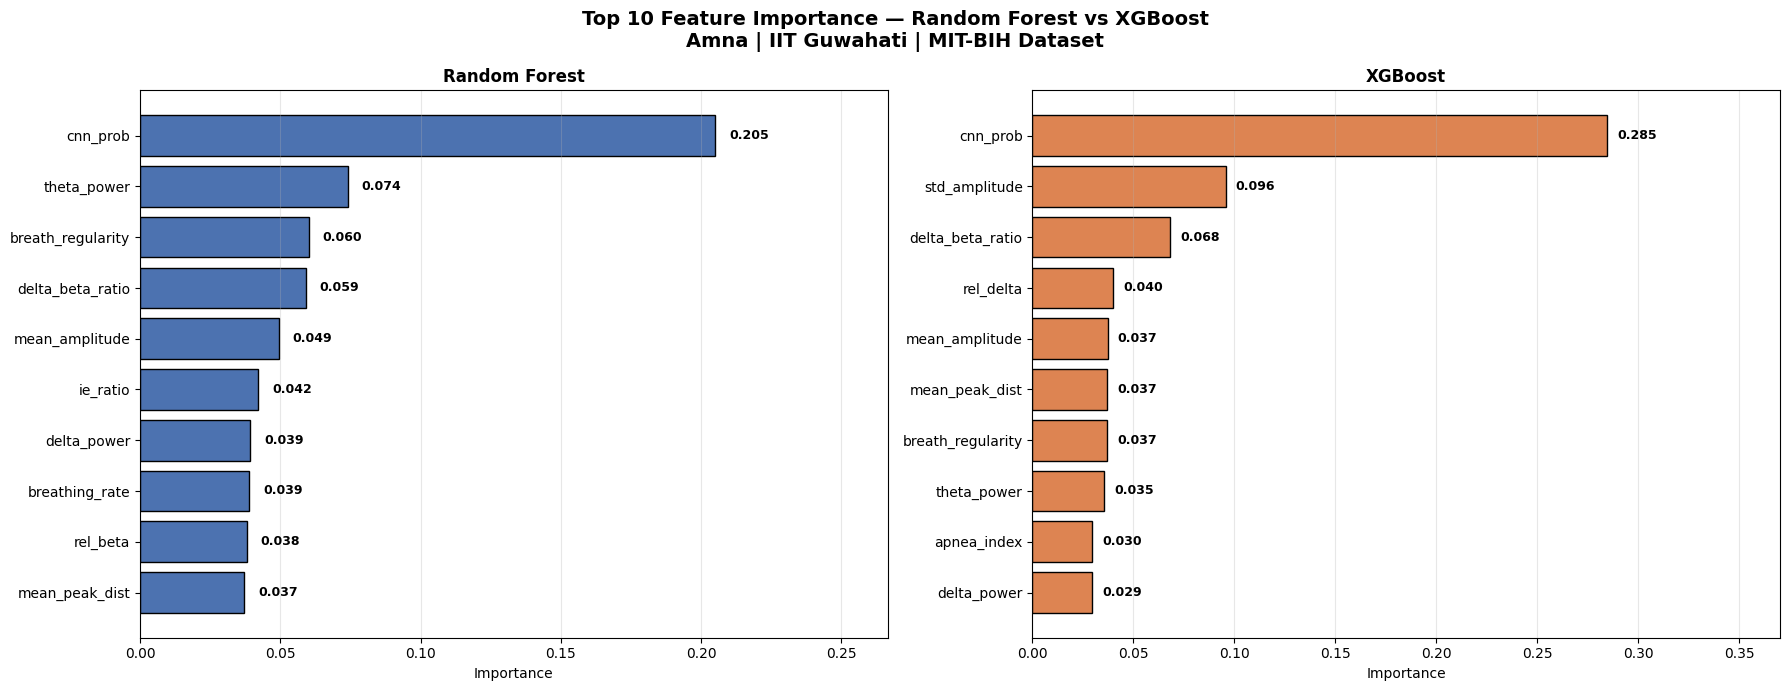

Plot saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Top 10 Feature Importance — Random Forest vs XGBoost\nAmna | IIT Guwahati | MIT-BIH Dataset",
             fontsize=14, fontweight='bold')

# --- Random Forest plot ---
ax1 = axes[0]
top10_rf = df_rf.head(10).sort_values('importance')
bars1 = ax1.barh(top10_rf['feature'], top10_rf['importance'], color='#4C72B0', edgecolor='black')
ax1.set_title("Random Forest", fontweight='bold', fontsize=12)
ax1.set_xlabel("Importance")
ax1.set_xlim(0, max(top10_rf['importance']) * 1.3)
ax1.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars1, top10_rf['importance']):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

# --- XGBoost plot ---
ax2 = axes[1]
top10_xgb = df_xgb.head(10).sort_values('importance')
bars2 = ax2.barh(top10_xgb['feature'], top10_xgb['importance'], color='#DD8452', edgecolor='black')
ax2.set_title("XGBoost", fontweight='bold', fontsize=12)
ax2.set_xlabel("Importance")
ax2.set_xlim(0, max(top10_xgb['importance']) * 1.3)
ax2.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars2, top10_xgb['importance']):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("/drive/MyDrive/shhs-data/feature_importance_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

## 04: Identify Common Important Features
We find which features both Random Forest and XGBoost agree
are important by checking the overlap between their top 10
lists. Features that both models agree on are the most
trustworthy indicators of sleep apnea.

In [ ]:
top10_rf_features = set(df_rf.head(10)['feature'])
top10_xgb_features = set(df_xgb.head(10)['feature'])

common_features = top10_rf_features.intersection(top10_xgb_features)
rf_only = top10_rf_features - top10_xgb_features
xgb_only = top10_xgb_features - top10_rf_features

print(f"Feature Agreement Analysis:")
print(f"\nFeatures in BOTH top 10 lists ({len(common_features)}):")
for f in common_features:
    print(f"  - {f}")

print(f"\nOnly in Random Forest top 10 ({len(rf_only)}):")
for f in rf_only:
    print(f"  - {f}")

print(f"\nOnly in XGBoost top 10 ({len(xgb_only)}):")
for f in xgb_only:
    print(f"  - {f}")

Feature Agreement Analysis:

Features in BOTH top 10 lists (7):
  - breath_regularity
  - theta_power
  - delta_beta_ratio
  - delta_power
  - mean_peak_dist
  - mean_amplitude
  - cnn_prob

Only in Random Forest top 10 (3):
  - ie_ratio
  - rel_beta
  - breathing_rate

Only in XGBoost top 10 (3):
  - rel_delta
  - apnea_index
  - std_amplitude


## 05: Save the Feature Importance Comparison Results
We save the agreement analysis as a summary table.
This supports our discussion section about which signals
and features are most reliable for sleep apnea detection.

In [ ]:
summary = {
    'Category': ['Common to Both Models', 'Random Forest Only', 'XGBoost Only'],
    'Count': [len(common_features), len(rf_only), len(xgb_only)],
    'Features': [', '.join(common_features), ', '.join(rf_only), ', '.join(xgb_only)]
}

df_summary = pd.DataFrame(summary)
df_summary.to_csv("/drive/MyDrive/shhs-data/feature_importance_agreement.csv", index=False)

print(f"Summary saved")
print(df_summary.to_string(index=False))

Summary saved
             Category  Count                                                                                                Features
Common to Both Models      7 breath_regularity, theta_power, delta_beta_ratio, delta_power, mean_peak_dist, mean_amplitude, cnn_prob
   Random Forest Only      3                                                                      ie_ratio, rel_beta, breathing_rate
         XGBoost Only      3                                                                   rel_delta, apnea_index, std_amplitude
